In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [5]:
df = pd.read_csv("/content/Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [7]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [8]:
X = df[['area','bedrooms']]

y = df['price']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = LinearRegression()

In [11]:
model.fit(X_train,y_train)

LinearRegression()

In [12]:
print("Intercept :", model.intercept_)
print("Coefficient :")

for feature,coef in zip(X.columns,model.coef_):
  print(f"{feature} : {coef}")

Intercept : 642086.4086518651
Coefficient :
area : 389.22573013133035
bedrooms : 695678.6670515896


In [13]:
y_pred = model.predict(X_test)

In [14]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

print(comparison.head(10))

     Actual Price  Predicted Price
316       4060000     5.721233e+06
77        6650000     5.259090e+06
360       3710000     3.605916e+06
90        6440000     4.675251e+06
493       2800000     4.270456e+06
209       4900000     5.344719e+06
176       5250000     6.045326e+06
249       4543000     5.367037e+06
516       2450000     3.294535e+06
426       3353000     3.780032e+06


In [15]:
print("R2 Score :", r2_score(y_test,y_pred))
print("MSE :", mean_squared_error(y_test,y_pred))

R2 Score : 0.3510473817558726
MSE : 3280176595474.013


In [16]:
area = float(input("Enter area (Square Feet): "))
bedrooms = int(input("Enter the number of bedrooms: "))

price = model.predict([[area,bedrooms]])

print("\nPredicted House Price = ${:,.2f}".format(price[0]))

Enter area (Square Feet): 88
Enter the number of bedrooms: 4

Predicted House Price = $3,459,052.94


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


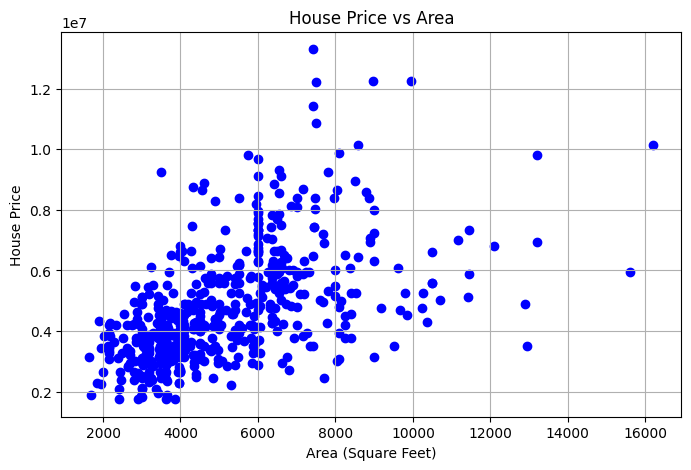

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df['area'],
            df['price'],
            color='blue'
            )

plt.xlabel("Area (Square Feet)")
plt.ylabel("House Price")
plt.title("House Price vs Area")

plt.grid(True)

plt.show()